# Structural Change Analysis

This notebook characterises *how* detection rules change structurally across both corpora:
**Splunk Security Content (SSC)** and **Sigma**.

We operate at the level of primitive structural operations derived from the PG-IR
(Predicate-Graph Intermediate Representation) alignment, then aggregate to lineage-level
structural evolution patterns.

### Outputs
| Cell | Output |
|------|--------|
| Figure 4 | Primitive structural operation frequency (horizontal bar chart, one panel per corpus) |
| Figure 5 | Primitive-op co-occurrence heatmap (multi-label revision steps, combined SSC+Sigma corpus) |
| Table 4  | Structural-operation coverage distribution (`\\label{tab:structural-coverage}`) |
| Table 5  | Structural evolution pattern prevalence (`\\label{tab:structural-patterns}`) |

In [4]:
# ── Imports and configuration ──────────────────────────────────────────────
import json
import pickle
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_colwidth', 90)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_rows', 100)

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT   = Path('../..').resolve()
BUILD_DATA  = REPO_ROOT / 'data_prep' / 'build_data'
ALIGN_DATA  = REPO_ROOT / 'data_prep' / 'align_data'
IR_DATA     = REPO_ROOT / 'data_prep' / 'ir_data'
ALIGN_SRC   = REPO_ROOT / 'data_prep' / 'align_src'
CACHE_DIR   = Path('.') / '.cache'
FIGURES_DIR = Path('../figures')
CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Wire structural_ops_helpers from align_src/
if str(ALIGN_SRC) not in sys.path:
    sys.path.insert(0, str(ALIGN_SRC))

# ── Dataset labels ─────────────────────────────────────────────────────────
DATASETS = {
    'SSC':   'ssc',
    'Sigma': 'sigma',
}

print(f'REPO_ROOT : {REPO_ROOT}')
print(f'ALIGN_SRC : {ALIGN_SRC}')
print(f'IR_DATA   : {IR_DATA}')

REPO_ROOT : /Users/elena/Desktop/Evolution-of-Log-Based-Detection-Rules
ALIGN_SRC : /Users/elena/Desktop/Evolution-of-Log-Based-Detection-Rules/data_prep/align_src
IR_DATA   : /Users/elena/Desktop/Evolution-of-Log-Based-Detection-Rules/data_prep/ir_data


## Primitive Structural Operations — Taxonomy

### Level of analysis

We focus on **Level-2 (logical-structure) changes** — modifications to the Boolean AND/OR/NOT
skeleton and predicate leaves. Level-1 (value-level) predicate attribute changes (`PRED_UPDATE`)
are tracked separately as a coverage baseline only.

**Canonical trees** are used throughout (`build_canonical_tree`), which:
- Flattens associative operators: `AND(AND(a,b),c)` → `AND(a,b,c)`
- Sorts commutative children to canonical order
- Annotates polarity context (POS/NEG)

This means 'adding a child under AND' is well-defined even across representation variants.

---

### Operational definitions — retained operations

| Op | Definition | Evidence field |
|----|------------|----------------|
| **OR_ADD** | ≥1 unmatched pred leaf in B, whose nearest O:AND/O:OR ancestor is **matched** (already existed in A) and is **O:OR** | `n_pred_added_under_existing_or > 0` |
| **OR_REMOVE** | ≥1 unmatched pred leaf in A, nearest matched ancestor is O:OR | `n_pred_removed_from_existing_or > 0` |
| **AND_ADD** | ≥1 unmatched pred leaf in B, nearest matched ancestor is O:AND or root-level | `n_pred_added_under_existing_and + n_pred_added_at_root > 0` |
| **AND_REMOVE** | ≥1 unmatched pred leaf in A, nearest matched ancestor is O:AND or root | `n_pred_removed_from_existing_and + n_pred_removed_at_root > 0` |
| **BRANCH_ADD** | ≥1 new op node introduced in B with predicate descendants and at least one unmatched descendant predicate; excludes preserved-group rewrites | `n_new_or_with_preds + n_new_and_with_preds > 0` |
| **BRANCH_REMOVE** | ≥1 removed op node from A with predicate descendants and at least one unmatched descendant predicate; excludes preserved-group rewrites | `n_removed_or_with_preds + n_removed_and_with_preds > 0` |
| **PRED_SCOPE_REASSIGN** | Matched predicate moves to a different nearest enclosing Boolean scope/root | `n_pred_scope_reassign > 0` |
| **PRED_CONTEXT_RELABEL** | Matched predicate stays in the same scope but its enclosing operator type changes (AND↔OR) | `n_pred_context_relabel > 0` |
| **PRED_UPDATE** | ≥1 matched pred-pair with different field/op/value | `n_pred_update > 0` (Level-1 only) |

### Key disambiguation decisions

- **OR_ADD vs BRANCH_ADD**: OR_ADD requires the OR scope to exist already; BRANCH_ADD requires
  a *new* scope. They are mutually exclusive for the same pred leaf. However, a step can carry
  both (expanding an existing OR and introducing a new OR scope).

- **Root-level preds are AND-context.** A pred with no O:AND/O:OR ancestor is at root level.
  Root-level predicates are implicitly conjunctive (AND semantics); included in AND_ADD/AND_REMOVE.

- **PRED_SCOPE_REASSIGN vs PRED_CONTEXT_RELABEL**: Scope reassignment takes priority — if the
  nearest-scope *identity* changes, we count reassignment even if the operator label also differs.
  Context relabelling is recorded only when scope identity is preserved but operator type flips.

- **PRED_UPDATE is excluded from core analysis.** It is a Level-1 (value-level) change,
  retained for coverage completeness only.

- **Multi-labelling is intentional.** A step can carry OR_ADD + AND_ADD simultaneously.

## Data Loading

We load non-noop revision steps, then build a selective PGIR index containing only the
two PGIR records required per step (version A and version B). This avoids loading the
full ~110K-record PGIR files into memory at once.

In [5]:
from structural_ops_helpers import (
    ALL_PRIMITIVE_OPS, CORE_OPS,
    OP_OR_ADD, OP_OR_REMOVE, OP_AND_ADD, OP_AND_REMOVE,
    OP_PRED_UPDATE, OP_PRED_SCOPE_REASSIGN, OP_PRED_CONTEXT_RELABEL,
    OP_BRANCH_ADD, OP_BRANCH_REMOVE,
    PAT_PURE_EXPANSION, PAT_PURE_CONTRACTION, PAT_MIXED,
    PAT_RESTRUCTURING_ONLY, PAT_PRED_VALUE_UPDATE_ONLY,
    PAT_NO_STRUCTURAL_EDITS, PAT_COMPLEX_UNCLASSIFIED,
    PATTERN_ORDER,
    load_pgir_index_selective,
    detect_structural_ops_for_pair,
    sequence_metrics,
    assign_dominant_pattern,
)


def load_nonnoop_steps(repo: str):
    """Load all non-noop steps from align_data/all_steps_{repo}.jsonl."""
    path = ALIGN_DATA / f'all_steps_{repo}.jsonl'
    steps = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if not rec.get('is_noop', True):
                steps.append(rec)
    return steps


def needed_pgir_keys(steps):
    """Collect (lineage_id, version_index) keys for both sides of every step."""
    keys = set()
    for s in steps:
        lid = s['lineage_id']
        keys.add((lid, s['version_a']))
        keys.add((lid, s['version_b']))
    return keys


print('Loading non-noop steps...')
all_steps = {}
for label, repo in DATASETS.items():
    steps = load_nonnoop_steps(repo)
    all_steps[label] = steps
    print(f'  {label}: {len(steps):,} non-noop steps')

print('\nBuilding selective PGIR indices...')
pgir_index = {}
for label, repo in DATASETS.items():
    keys = needed_pgir_keys(all_steps[label])
    pgir_path = IR_DATA / f'pgir_{repo}_nonempty.jsonl'
    pgir_index[label] = load_pgir_index_selective(pgir_path, keys)
    print(f'  {label}: loaded {len(pgir_index[label]):,} PGIR records (needed {len(keys):,} keys)')

Loading non-noop steps...
  SSC: 4,668 non-noop steps
  Sigma: 8,234 non-noop steps

Building selective PGIR indices...
  SSC: loaded 8,135 PGIR records (needed 8,135 keys)
  Sigma: loaded 13,556 PGIR records (needed 13,556 keys)


## Structural Op Detection (with Cache)

We run `detect_structural_ops_for_pair` for every non-noop step and pickle the results.
Re-running this cell is fast once the cache exists.

In [3]:
def structural_ops_helper_fingerprint() -> str:
    """Fingerprint alignment code so cached detections stay in sync with code changes."""
    import hashlib
    digest = hashlib.sha256()
    for rel_path in ['structural_ops_helpers.py', 'pgir_align.py']:
        digest.update((ALIGN_SRC / rel_path).read_bytes())
    return digest.hexdigest()


def run_detection_cached(label: str, repo: str, steps, pgir_idx) -> list:
    """Run structural op detection for all steps, with pickle cache."""
    cache_path = CACHE_DIR / f'struct_ops_{repo}.pkl'
    helper_fp = structural_ops_helper_fingerprint()
    if cache_path.exists():
        with cache_path.open('rb') as f:
            cached = pickle.load(f)

        if isinstance(cached, dict) and cached.get('helper_fingerprint') == helper_fp:
            print(f'  [{label}] Loading from cache: {cache_path}')
            return cached['results']

        if isinstance(cached, list):
            print(f'  [{label}] Ignoring legacy cache (no helper fingerprint): {cache_path}')
        else:
            print(f'  [{label}] Cache is stale for current alignment helper code: {cache_path}')

    print(f'  [{label}] Running detection on {len(steps):,} steps (no cache)...')
    results = []
    missing = 0
    for i, step in enumerate(steps):
        lid = step['lineage_id']
        key_a = (lid, step['version_a'])
        key_b = (lid, step['version_b'])
        obj_a = pgir_idx.get(key_a)
        obj_b = pgir_idx.get(key_b)
        if obj_a is None or obj_b is None:
            missing += 1
            results.append(None)
            continue
        try:
            det = detect_structural_ops_for_pair(obj_a, obj_b)
            det['lineage_id'] = lid
            det['version_a']  = step['version_a']
            det['version_b']  = step['version_b']
            results.append(det)
        except Exception as exc:
            results.append({'error': str(exc), 'lineage_id': lid,
                            'version_a': step['version_a'],
                            'version_b': step['version_b']})
        if (i + 1) % 5000 == 0:
            print(f'    {i+1:,} / {len(steps):,} done ...')

    if missing:
        print(f'  [{label}] WARNING: {missing} steps skipped (PGIR record not found)')
    with cache_path.open('wb') as f:
        pickle.dump({
            'helper_fingerprint': helper_fp,
            'results': results,
        }, f)
    print(f'  [{label}] Cached to {cache_path}')
    return results


print('Running / loading structural op detection:')
det_results = {}
for label, repo in DATASETS.items():
    det_results[label] = run_detection_cached(
        label, repo, all_steps[label], pgir_index[label]
    )
    valid = [r for r in det_results[label] if r is not None and 'error' not in r]
    print(f'  {label}: {len(valid):,} valid detection results')

Running / loading structural op detection:
  [SSC] Running detection on 4,668 steps (no cache)...
  [SSC] Cached to .cache/struct_ops_ssc.pkl
  SSC: 4,668 valid detection results
  [Sigma] Running detection on 8,234 steps (no cache)...
    5,000 / 8,234 done ...
  [Sigma] Cached to .cache/struct_ops_sigma.pkl
  Sigma: 8,234 valid detection results


## Figure 4 — Primitive Structural Operation Frequency

For each corpus: what fraction of predicate-changing revision steps trigger each primitive
operation?  Core structural ops only (excludes `PRED_UPDATE`, which is Level-1).

Color coding: **blue** = add/expand class (OR_ADD, AND_ADD, BRANCH_ADD);
**red** = remove/contract class (OR_REMOVE, AND_REMOVE, BRANCH_REMOVE);
**green** = PRED_SCOPE_REASSIGN; **gold** = PRED_CONTEXT_RELABEL.

Saved: ../figures/fig_structural_op_freq.pdf


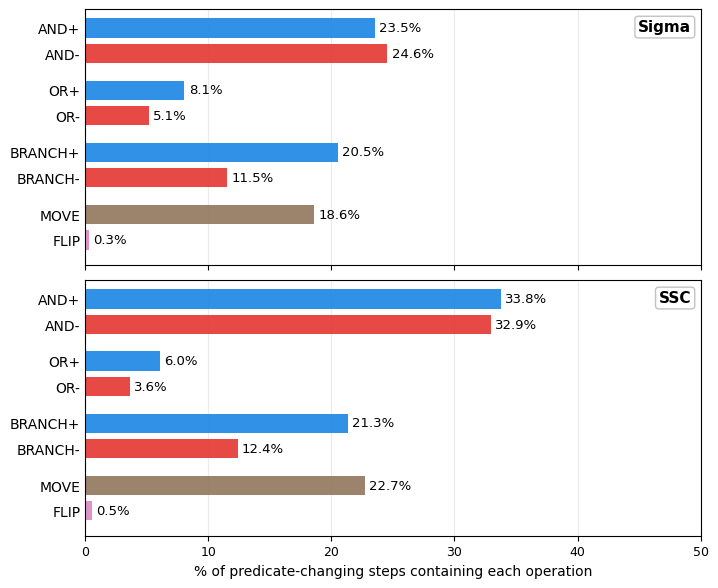

In [6]:
def savefig(name):
    out = FIGURES_DIR / f'{name}.pdf'
    plt.savefig(out, bbox_inches='tight')
    print(f'Saved: {out}')


# ── Colour classes and plotting order ───────────────────────────────────────
CLASS_COLORS = {
    'ADD':              '#1E88E5',   # blue  — OR_ADD, AND_ADD, BRANCH_ADD
    'REMOVE':           '#E53935',   # red   — OR_REMOVE, AND_REMOVE, BRANCH_REMOVE
    'SCOPE_REASSIGN':   '#2E7D32',   # green — PRED_SCOPE_REASSIGN
    'CONTEXT_RELABEL':  '#F9A825',   # gold  — PRED_CONTEXT_RELABEL
}

ADD_OPS    = {OP_OR_ADD, OP_AND_ADD, OP_BRANCH_ADD}
REMOVE_OPS = {OP_OR_REMOVE, OP_AND_REMOVE, OP_BRANCH_REMOVE}
PLOT_OPS_ORDER = [
    OP_OR_ADD,
    OP_OR_REMOVE,
    OP_AND_ADD,
    OP_AND_REMOVE,
    OP_BRANCH_ADD,
    OP_BRANCH_REMOVE,
    OP_PRED_SCOPE_REASSIGN,
    OP_PRED_CONTEXT_RELABEL,
]
OP_PLOT_LABELS = {
    OP_AND_ADD: 'and+',
    OP_AND_REMOVE: 'and-',
    OP_OR_ADD: 'or+',
    OP_OR_REMOVE: 'or-',
    OP_BRANCH_ADD: 'branch+',
    OP_BRANCH_REMOVE: 'branch-',
    OP_PRED_SCOPE_REASSIGN: 'move',
    OP_PRED_CONTEXT_RELABEL: 'flip',
}

def op_color(op):
    if op in ADD_OPS:
        return CLASS_COLORS['ADD']
    if op in REMOVE_OPS:
        return CLASS_COLORS['REMOVE']
    if op == OP_PRED_SCOPE_REASSIGN:
        return CLASS_COLORS['SCOPE_REASSIGN']
    if op == OP_PRED_CONTEXT_RELABEL:
        return CLASS_COLORS['CONTEXT_RELABEL']
    return '#9E9E9E'


def compute_op_freq(det_list):
    valid = [r for r in det_list if r is not None and 'error' not in r]
    counts = {op: sum(1 for r in valid if r['ops'].get(op, False))
              for op in ALL_PRIMITIVE_OPS}
    return counts, len(valid)


freq_data = {}
for label in DATASETS:
    counts, total = compute_op_freq(det_results[label])
    freq_data[label] = {'counts': counts, 'total': total}
    
VARIANT_CLASS_COLORS = {
    'ADD': '#1E88E5',
    'REMOVE': '#E53935',
    'SCOPE_REASSIGN': '#937860',
    'CONTEXT_RELABEL': '#DA8BC3',
}

VARIANT_OPS_ORDER = [
    OP_AND_ADD,
    OP_AND_REMOVE,
    OP_OR_ADD,
    OP_OR_REMOVE,
    OP_BRANCH_ADD,
    OP_BRANCH_REMOVE,
    OP_PRED_SCOPE_REASSIGN,
    OP_PRED_CONTEXT_RELABEL,
]

VARIANT_DATASET_ORDER = ['Sigma', 'SSC']
VARIANT_LABELS = {
    OP_AND_ADD: 'AND+',
    OP_AND_REMOVE: 'AND-',
    OP_OR_ADD: 'OR+',
    OP_OR_REMOVE: 'OR-',
    OP_BRANCH_ADD: 'BRANCH+',
    OP_BRANCH_REMOVE: 'BRANCH-',
    OP_PRED_SCOPE_REASSIGN: 'MOVE',
    OP_PRED_CONTEXT_RELABEL: 'FLIP',
}

VARIANT_YPOS = {
    OP_AND_ADD: 0.0,
    OP_AND_REMOVE: 0.82,
    OP_OR_ADD: 2.0,
    OP_OR_REMOVE: 2.82,
    OP_BRANCH_ADD: 4.0,
    OP_BRANCH_REMOVE: 4.82,
    OP_PRED_SCOPE_REASSIGN: 6.0,
    OP_PRED_CONTEXT_RELABEL: 6.82,
}

def variant_op_color(op):
    if op in ADD_OPS:
        return VARIANT_CLASS_COLORS['ADD']
    if op in REMOVE_OPS:
        return VARIANT_CLASS_COLORS['REMOVE']
    if op == OP_PRED_SCOPE_REASSIGN:
        return VARIANT_CLASS_COLORS['SCOPE_REASSIGN']
    if op == OP_PRED_CONTEXT_RELABEL:
        return VARIANT_CLASS_COLORS['CONTEXT_RELABEL']
    return '#9E9E9E'


fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.9), sharex=True)

for ax, label in zip(axes, VARIANT_DATASET_ORDER):
    counts = freq_data[label]['counts']
    total = freq_data[label]['total']
    ops = [op for op in VARIANT_OPS_ORDER if op in counts]
    pcts = [100 * counts[op] / total for op in ops]
    ypos = [VARIANT_YPOS[op] for op in ops]
    colors = [variant_op_color(op) for op in ops]
    ylabels = [VARIANT_LABELS[op] for op in ops]

    bars = ax.barh(ypos, pcts, color=colors, edgecolor='none', alpha=0.92, height=0.62)
    ax.set_yticks(ypos, labels=ylabels)
    for tick in ax.get_yticklabels():
        tick.set_fontvariant('small-caps')
        tick.set_fontsize(10)

    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.25)
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', which='both', left=False, right=False, length=0)
    ax.set_xlim(0, 50)
    ax.set_ylim(max(ypos) + 0.8, -0.6)

    for bar, pct in zip(bars, pcts):
        if pct > 0:
            ax.text(
                pct + 0.35,
                bar.get_y() + bar.get_height() / 2,
                f'{pct:.1f}%',
                va='center',
                fontsize=9.5,
                fontweight='normal',
            )

    ax.text(
        0.985,
        0.96,
        label,
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=11,
        fontweight='semibold',
        bbox=dict(boxstyle='round,pad=0.22', facecolor='white', edgecolor='0.75', alpha=0.95),
    )

axes[-1].set_xlabel(
    '% of predicate-changing steps containing each operation',
    fontsize=10,
)
plt.tight_layout(pad=0.7)
savefig('fig_structural_op_freq')
plt.show()

## Figure 5 — Primitive-Op Co-Occurrence Heatmap

Among revision steps that trigger **more than one** core structural operation simultaneously,
how often do pairs of ops co-occur?

Cell (i, j) = P(column op | row op):

$$P(\text{op}_j \mid \text{op}_i) = \frac{|\{\text{multi-label steps with both op}_i \text{ and op}_j\}|}{|\{\text{multi-label steps with op}_i\}|}$$

This figure pools **SSC** and **Sigma** into a single combined corpus (**Both**).

Saved: ../figures/fig_structural_op_cooccurrence.pdf


/var/folders/j4/1g43plmj3xl1lgh8rsjt7r8r0000gn/T/ipykernel_25130/3663005825.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0.25)


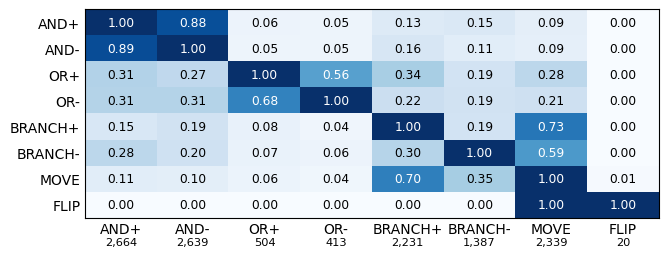


── Co-occurrence reference (>40% pairs highlighted) ──

Both (n=5,412 multi-label steps):


,AND_ADD,AND_REMOVE,OR_ADD,OR_REMOVE,BRANCH_ADD,BRANCH_REMOVE,PRED_SCOPE_REASSIGN,PRED_CONTEXT_RELABEL
AND_ADD,1.000,0.880,0.059,0.047,0.128,0.146,0.095,0.000
AND_REMOVE,0.888,1.000,0.051,0.048,0.161,0.106,0.087,0.000
OR_ADD,0.310,0.266,1.000,0.560,0.343,0.187,0.278,0.000
OR_REMOVE,0.305,0.308,0.683,1.000,0.220,0.194,0.211,0.000
BRANCH_ADD,0.153,0.190,0.078,0.041,1.000,0.187,0.729,0.000
BRANCH_REMOVE,0.280,0.203,0.068,0.058,0.301,1.000,0.591,0.000
PRED_SCOPE_REASSIGN,0.108,0.098,0.060,0.037,0.695,0.351,1.000,0.009
PRED_CONTEXT_RELABEL,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000


  High co-occurrence pairs (>40%):
    AND_ADD → AND_REMOVE: 0.88
    AND_REMOVE → AND_ADD: 0.89
    OR_ADD → OR_REMOVE: 0.56
    OR_REMOVE → OR_ADD: 0.68
    BRANCH_ADD → PRED_SCOPE_REASSIGN: 0.73
    BRANCH_REMOVE → PRED_SCOPE_REASSIGN: 0.59
    PRED_SCOPE_REASSIGN → BRANCH_ADD: 0.70
    PRED_CONTEXT_RELABEL → PRED_SCOPE_REASSIGN: 1.00


In [7]:
def multi_label_dets(det_list):
    """Return detection results where >1 CORE_OPS are active (multi-label steps)."""
    valid = [r for r in det_list if r is not None and 'error' not in r]
    return [r for r in valid
            if sum(1 for op in CORE_OPS if r['ops'].get(op, False)) > 1]


def cooccurrence_matrix(multi, op_list):
    """P(col | row) co-occurrence matrix from a list of detection result dicts."""
    n  = len(op_list)
    co = np.zeros((n, n), dtype=int)
    for r in multi:
        for i, oi in enumerate(op_list):
            for j, oj in enumerate(op_list):
                if r['ops'].get(oi, False) and r['ops'].get(oj, False):
                    co[i, j] += 1
    diag = np.diag(co).clip(1)
    co_n = co / diag[:, None]   # P(col | row)
    return co_n, np.diag(co)


op_cols = [
    OP_AND_ADD,
    OP_AND_REMOVE,
    OP_OR_ADD,
    OP_OR_REMOVE,
    OP_BRANCH_ADD,
    OP_BRANCH_REMOVE,
    OP_PRED_SCOPE_REASSIGN,
    OP_PRED_CONTEXT_RELABEL,
]
op_axis_labels = {
    OP_AND_ADD: 'AND+',
    OP_AND_REMOVE: 'AND-',
    OP_OR_ADD: 'OR+',
    OP_OR_REMOVE: 'OR-',
    OP_BRANCH_ADD: 'BRANCH+',
    OP_BRANCH_REMOVE: 'BRANCH-',
    OP_PRED_SCOPE_REASSIGN: 'MOVE',
    OP_PRED_CONTEXT_RELABEL: 'FLIP',
}
axis_labels = [op_axis_labels[op] for op in op_cols]
multi_both = []
for label in DATASETS:
    multi_both.extend(multi_label_dets(det_results[label]))

fig, (ax, ax_counts) = plt.subplots(
    2, 1,
    figsize=(7.4, 3.15),
    gridspec_kw={'height_ratios': [12, 1.7], 'hspace': 0.04},
)
n_multi = len(multi_both)

if n_multi == 0:
    ax.text(0.5, 0.5, 'Both: no multi-label steps',
            ha='center', va='center', transform=ax.transAxes, fontsize=9)
    ax_counts.axis('off')
else:
    co_n, op_counts = cooccurrence_matrix(multi_both, op_cols)

    im = ax.imshow(co_n, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(op_cols)))
    ax.set_yticks(range(len(op_cols)))
    ax.set_xticklabels(axis_labels, rotation=0, ha='center', fontsize=10)
    ax.set_yticklabels(axis_labels, fontsize=10)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontvariant('small-caps')
        tick.set_fontsize(10)
    ax.tick_params(axis='both', which='both', length=0)
    for i in range(len(op_cols)):
        for j in range(len(op_cols)):
            v = co_n[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=8.8,
                    color='white' if v > 0.5 else 'black')

    ax_counts.set_xlim(-0.5, len(op_cols) - 0.5)
    ax_counts.set_ylim(0, 1)
    ax_counts.axis('off')
    for j, n_op in enumerate(op_counts):
        ax_counts.text(j, 0.34, f'{n_op:,}', ha='center', va='center', fontsize=8.2)

plt.tight_layout(pad=0.25)
savefig('fig_structural_op_cooccurrence')
plt.show()

# ── Reference tables + high co-occurrence pairs (>40%) ────────────────────
print('\n── Co-occurrence reference (>40% pairs highlighted) ──')
if not multi_both:
    print('\nBoth: no multi-label steps')
else:
    co_n, _ = cooccurrence_matrix(multi_both, op_cols)
    df_co = pd.DataFrame(np.round(co_n, 3), index=op_cols, columns=op_cols)
    print(f'\nBoth (n={len(multi_both):,} multi-label steps):')
    display(df_co)
    print('  High co-occurrence pairs (>40%):')
    found = False
    for i, ri in enumerate(op_cols):
        for j, cj in enumerate(op_cols):
            if i != j and co_n[i, j] > 0.4:
                print(f'    {ri} → {cj}: {co_n[i, j]:.2f}')
                found = True
    if not found:
        print('    (none above threshold)')

## Figure 5 Follow-Up — Why Do `flip` and `move` Co-Occur?

The heatmap is computed only over **multi-label** steps, so a value of `1.00` means:
among steps in the Figure 2 population that trigger `PRED_CONTEXT_RELABEL`, all of them
also trigger `PRED_SCOPE_REASSIGN`. The cell below prints a few such examples and compares
that heatmap population against the full set of valid predicate-changing steps.

In [8]:
N_MOVE_FLIP_EXAMPLES = 5

def active_ops_list(det):
    return [op for op in ALL_PRIMITIVE_OPS if det['ops'].get(op, False)]


def is_multi_label_core_step(det):
    return sum(1 for op in CORE_OPS if det['ops'].get(op, False)) > 1


def valid_step_rows(label):
    rows = []
    for step, det in zip(all_steps[label], det_results[label]):
        if det is None or 'error' in det:
            continue
        rows.append((label, step, det))
    return rows


def summarize_move_flip(rows, title):
    n_total = len(rows)
    n_flip = sum(1 for _, _, det in rows if det['ops'].get(OP_PRED_CONTEXT_RELABEL, False))
    n_move = sum(1 for _, _, det in rows if det['ops'].get(OP_PRED_SCOPE_REASSIGN, False))
    n_both = sum(
        1 for _, _, det in rows
        if det['ops'].get(OP_PRED_CONTEXT_RELABEL, False)
        and det['ops'].get(OP_PRED_SCOPE_REASSIGN, False)
    )
    n_flip_only = sum(
        1 for _, _, det in rows
        if det['ops'].get(OP_PRED_CONTEXT_RELABEL, False)
        and not det['ops'].get(OP_PRED_SCOPE_REASSIGN, False)
    )
    n_move_only = sum(
        1 for _, _, det in rows
        if det['ops'].get(OP_PRED_SCOPE_REASSIGN, False)
        and not det['ops'].get(OP_PRED_CONTEXT_RELABEL, False)
    )

    print(title)
    print(f'  total steps: {n_total:,}')
    print(f'  flip steps: {n_flip:,}')
    print(f'  move steps: {n_move:,}')
    print(f'  both flip+move: {n_both:,}')
    print(f'  flip-only: {n_flip_only:,}')
    print(f'  move-only: {n_move_only:,}')
    print(f'  P(move | flip): {n_both / n_flip:.2f}' if n_flip else '  P(move | flip): undefined')
    print(f'  P(flip | move): {n_both / n_move:.2f}' if n_move else '  P(flip | move): undefined')
    return {
        'n_total': n_total,
        'n_flip': n_flip,
        'n_move': n_move,
        'n_both': n_both,
        'n_flip_only': n_flip_only,
        'n_move_only': n_move_only,
    }


all_valid_rows = []
multi_rows = []
for label in DATASETS:
    rows = valid_step_rows(label)
    all_valid_rows.extend(rows)
    multi_rows.extend([(repo, step, det) for repo, step, det in rows if is_multi_label_core_step(det)])

print('=== Combined corpus counts ===')
all_stats = summarize_move_flip(all_valid_rows, 'All valid predicate-changing steps')
print()
multi_stats = summarize_move_flip(multi_rows, 'Figure 2 population: multi-label core-op steps only')

examples = []
for label, step, det in multi_rows:
    if not det['ops'].get(OP_PRED_CONTEXT_RELABEL, False):
        continue
    if not det['ops'].get(OP_PRED_SCOPE_REASSIGN, False):
        continue

    key_a = (step['lineage_id'], step['version_a'])
    key_b = (step['lineage_id'], step['version_b'])
    obj_a = pgir_index[label][key_a]
    obj_b = pgir_index[label][key_b]

    events = []
    if 'extract_context_relabel_events' in globals():
        events = extract_context_relabel_events(obj_a, obj_b)
    elif det.get('evidence', {}).get('context_relabel_directions'):
        events = [{'direction': d} for d in det['evidence']['context_relabel_directions']]

    examples.append({
        'corpus': label,
        'lineage_id': step['lineage_id'],
        'version_a': step['version_a'],
        'version_b': step['version_b'],
        'active_ops': active_ops_list(det),
        'flip_dirs': [e.get('direction', '?') for e in events],
        'evidence': det.get('evidence', {}),
        'spl_a': obj_a.get('spl', '<missing spl>'),
        'spl_b': obj_b.get('spl', '<missing spl>'),
    })
    if len(examples) >= N_MOVE_FLIP_EXAMPLES:
        break

print(f'\n=== Example steps with both flip and move (up to {N_MOVE_FLIP_EXAMPLES}) ===')
if not examples:
    print('No multi-label flip+move examples found.')
else:
    for i, ex in enumerate(examples, start=1):
        print('=' * 88)
        print(f"Example {i}: {ex['corpus']} | {ex['lineage_id']} | v{ex['version_a']} -> v{ex['version_b']}")
        print('Active ops:', ', '.join(ex['active_ops']))
        if ex['flip_dirs']:
            print('Flip directions:', ', '.join(ex['flip_dirs']))
        else:
            print('Flip directions: none found by extractor')
        print('Evidence:', ex['evidence'])
        print('-' * 88)
        print('[A] SPL')
        print(ex['spl_a'])
        print()
        print('[B] SPL')
        print(ex['spl_b'])
        print()

print('=== Interpretation ===')
if multi_stats['n_flip'] and multi_stats['n_flip_only'] == 0:
    print('- In the Figure 2 population, every flip step also has at least one matched predicate whose nearest preserved boolean scope changes, so move is always present when flip is present.')
else:
    print('- The Figure 2 heatmap no longer shows perfect flip->move co-occurrence in the current run.')

if all_stats['n_flip_only'] > 0:
    print('- There are flip-only steps in the full valid corpus, but Figure 2 excludes them because it keeps only multi-label steps.')
else:
    print('- Even in the full valid corpus, flip currently appears only alongside other structural changes.')

print('- Operationally, this usually means one subset of matched predicates stays under a preserved scope whose operator flips (AND <-> OR), while another matched predicate crosses into a different nearest preserved scope in the same edit, which triggers move.')


=== Combined corpus counts ===
All valid predicate-changing steps
  total steps: 12,902
  flip steps: 50
  move steps: 2,593
  both flip+move: 20
  flip-only: 30
  move-only: 2,573
  P(move | flip): 0.40
  P(flip | move): 0.01

Figure 2 population: multi-label core-op steps only
  total steps: 5,412
  flip steps: 20
  move steps: 2,339
  both flip+move: 20
  flip-only: 0
  move-only: 2,319
  P(move | flip): 1.00
  P(flip | move): 0.01

=== Example steps with both flip and move (up to 5) ===
Example 1: SSC | lineage_03883 | v34 -> v35
Active ops: PRED_SCOPE_REASSIGN, PRED_CONTEXT_RELABEL, PRED_UPDATE
Flip directions: none found by extractor
Evidence: {'n_pred_added_under_existing_or': 0, 'n_pred_added_under_existing_and': 0, 'n_pred_added_at_root': 0, 'n_pred_added_under_new_scope': 0, 'n_pred_removed_from_existing_or': 0, 'n_pred_removed_from_existing_and': 0, 'n_pred_removed_at_root': 0, 'n_pred_removed_from_old_scope': 0, 'n_new_or_ops': 1, 'n_new_and_ops': 1, 'n_new_not_ops': 0, 'n_

## Table 4 — Structural Coverage Distribution

Per corpus: how many core structural operations are triggered in a single revision step?
Columns show the average, exact counts 0–4, a 5+ bucket, and the maximum.
The count for a step is the number of distinct core structural ops (out of 8) it triggers,
excluding `PRED_UPDATE`. Steps with only predicate-value updates therefore fall into bucket `0`.

In [8]:
def op_count_per_step(det_list):
    valid = [r for r in det_list if r is not None and 'error' not in r]
    return [sum(1 for op in CORE_OPS if r['ops'].get(op, False))
            for r in valid]


def format_cov_row(label, cnts):
    total = len(cnts)
    avg   = np.mean(cnts) if total else 0.0
    dist  = Counter(cnts)
    ge5   = sum(v for k, v in dist.items() if k >= 5)

    return {
        'Corpus':  label,
        'Steps':   f'{total:,}',
        'Avg ops': f'{avg:.2f}',
        '0':  f"{dist.get(0,0):,} ({100*dist.get(0,0)/total:.1f}\\%)" if total else '—',
        '1':  f"{dist.get(1,0):,} ({100*dist.get(1,0)/total:.1f}\\%)" if total else '—',
        '2':  f"{dist.get(2,0):,} ({100*dist.get(2,0)/total:.1f}\\%)" if total else '—',
        '3':  f"{dist.get(3,0):,} ({100*dist.get(3,0)/total:.1f}\\%)" if total else '—',
        '4':  f"{dist.get(4,0):,} ({100*dist.get(4,0)/total:.1f}\\%)" if total else '—',
        '5+': f"{ge5:,} ({100*ge5/total:.1f}\\%)" if total else '—',
        'Max': max(cnts) if cnts else 0,
    }


cov_rows = []
all_cnts = []
for label in DATASETS:
    cnts = op_count_per_step(det_results[label])
    all_cnts.extend(cnts)
    cov_rows.append(format_cov_row(label, cnts))

cov_rows.append(format_cov_row('Both', all_cnts))

df_cov = pd.DataFrame(cov_rows)
print('Structural Coverage Distribution (preview):')
display(df_cov)

Structural Coverage Distribution (preview):


,Corpus,Steps,Avg ops,0,1,2,3,4,5+,Max
0,SSC,"4,668",1.33,"1,106 (23.7\%)","1,386 (29.7\%)","1,849 (39.6\%)",198 (4.2\%),107 (2.3\%),22 (0.5\%),7
1,Sigma,"8,234",1.12,"3,111 (37.8\%)","1,887 (22.9\%)","2,584 (31.4\%)",455 (5.5\%),162 (2.0\%),35 (0.4\%),6
2,Both,"12,902",1.20,"4,217 (32.7\%)","3,273 (25.4\%)","4,433 (34.4\%)",653 (5.1\%),269 (2.1\%),57 (0.4\%),7


## Table 5: Structural Evolution Patterns

Distribution of structural evolution patterns across rule lineages with at least one predicate-
changing revision.

| Pattern | Condition |
|---------|-----------|
| PURE\_EXPANSION | Only expansion ops (OR_ADD, AND_ADD, BRANCH_ADD); no contraction |
| PURE\_CONTRACTION | Only contraction ops (OR_REMOVE, AND_REMOVE, BRANCH_REMOVE); no expansion |
| MIXED | Both expansion and contraction appear across steps |
| RESTRUCTURING\_ONLY | Scope-level changes only (BRANCH_ADD/REMOVE, PRED_SCOPE_REASSIGN, PRED_CONTEXT_RELABEL); zero expansion/contraction |
| PRED\_VALUE\_UPDATE\_ONLY | Only `PRED_UPDATE`; no structural ops |

In [14]:
def build_lineage_sequences(steps, det_list):
    """Group detection results by lineage_id, sorted by version_b."""
    seq = defaultdict(list)
    for step, det in zip(steps, det_list):
        if det is None or 'error' in det:
            continue
        lid = step['lineage_id']
        seq[lid].append((step['version_b'], det['ops']))
    return {lid: [ops for _, ops in sorted(v)] for lid, v in seq.items()}


def lineage_full_metrics(steps, det_list):
    """Return {lineage_id: {'pattern': str, 'oscillation_count': int}} for each lineage."""
    seqs = build_lineage_sequences(steps, det_list)
    out  = {}
    for lid, op_seq in seqs.items():
        met = sequence_metrics(op_seq)
        out[lid] = {
            'pattern':           assign_dominant_pattern(met),
            'oscillation_count': met.get('oscillation_count', 0),
        }
    return out


def load_aba_counts(repo: str):
    """Return {lineage_id: aba_count} from all_trajectories_{repo}.jsonl."""
    path = ALIGN_DATA / f'all_trajectories_{repo}.jsonl'
    aba  = {}
    with path.open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            aba[rec['lineage_id']] = rec.get('reverts', {}).get('aba_count', 0)
    return aba


# ── Build lineage metrics + load ABA counts ────────────────────────────────
lin_metrics = {}
aba_counts  = {}
for label, repo in DATASETS.items():
    lin_metrics[label] = lineage_full_metrics(all_steps[label], det_results[label])
    aba_counts[label]  = load_aba_counts(repo)
    print(f'{label}: {len(lin_metrics[label]):,} lineages with ≥1 non-noop step, '
          f'{sum(1 for v in aba_counts[label].values() if v > 0):,} with ABA reverts')

# convenience alias for pattern table
pat_results = {label: {lid: m['pattern'] for lid, m in lm.items()}
               for label, lm in lin_metrics.items()}

def fmt_count_pct(n, total):
    return f'{n:,} ({100 * n / total:.1f}%)' if total else '—'


pattern_rows = [
    ('value-only', PAT_PRED_VALUE_UPDATE_ONLY),
    ('expand-only', PAT_PURE_EXPANSION),
    ('contract-only', PAT_PURE_CONTRACTION),
    ('restructure-only', PAT_RESTRUCTURING_ONLY),
    ('mixed', PAT_MIXED),
]

totals = {label: len(pat_results[label]) for label in DATASETS}
rows = [{
    'Pattern': 'Number of Lineages',
    **{label: f'{totals[label]:,}' for label in DATASETS},
}]

for display_name, pattern in pattern_rows:
    row = {'Pattern': display_name}
    for label in DATASETS:
        n_pat = sum(1 for v in pat_results[label].values() if v == pattern)
        row[label] = fmt_count_pct(n_pat, totals[label])
    rows.append(row)

df_pat = pd.DataFrame(rows)[['Pattern', 'Sigma', 'SSC']]
display(df_pat)


SSC: 1,493 lineages with ≥1 non-noop step, 379 with ABA reverts
Sigma: 2,355 lineages with ≥1 non-noop step, 216 with ABA reverts


,Pattern,Sigma,SSC
0,Number of Lineages,"2,355","1,493"
1,value-only,460 (19.5%),118 (7.9%)
2,expand-only,300 (12.7%),393 (26.3%)
3,contract-only,256 (10.9%),98 (6.6%)
4,restructure-only,12 (0.5%),47 (3.1%)
5,mixed,"1,327 (56.3%)",837 (56.1%)


In [15]:
# ── MIXED lineage breakdown: intra-step vs inter-step mixing ──────────────
def classify_step_direction(ops):
    has_expand = any(ops.get(op, False) for op in ADD_OPS)
    has_contract = any(ops.get(op, False) for op in REMOVE_OPS)
    if has_expand and not has_contract:
        return 'expand'
    if has_contract and not has_expand:
        return 'contract'
    if has_expand and has_contract:
        return 'mixed'
    return 'other'


def fmt_pct(n, d):
    return f'{100 * n / d:.1f}' if d else '—'


def build_mixed_lineage_direction_table(label: str):
    per_lineage = defaultdict(list)
    for step, det in zip(all_steps[label], det_results[label]):
        if det is None or 'error' in det:
            continue

        lid = step['lineage_id']
        if lin_metrics[label].get(lid, {}).get('pattern') != PAT_MIXED:
            continue

        per_lineage[lid].append({
            'version_a': step['version_a'],
            'version_b': step['version_b'],
            'regime': classify_step_direction(det['ops']),
        })

    rows = []
    for lid, items in per_lineage.items():
        items = sorted(items, key=lambda r: (r['version_b'], r['version_a']))
        regimes = [item['regime'] for item in items]

        has_mixed_direction_step = any(r == 'mixed' for r in regimes)
        has_inter_step_alternation = ('expand' in regimes and 'contract' in regimes)

        rows.append({
            'lineage_id': lid,
            'has_mixed_direction_step': has_mixed_direction_step,
            'has_inter_step_alternation': has_inter_step_alternation,
            'only_intra_step_mixing': has_mixed_direction_step and not has_inter_step_alternation,
            'both_intra_and_inter': has_mixed_direction_step and has_inter_step_alternation,
            'only_inter_step_alternation': (not has_mixed_direction_step) and has_inter_step_alternation,
        })

    return pd.DataFrame(rows)


print('\n' + '=' * 72)
print('=== MIXED Lineages: Intra-Step vs Inter-Step Mixing ===')
print('Categories are mutually exclusive within lineages already labeled MIXED.')
print('=' * 72)

mixed_interstep_tables = {}
summary_rows = []

for label in DATASETS:
    df_mixed = build_mixed_lineage_direction_table(label)
    mixed_interstep_tables[label] = df_mixed

    total_mixed = len(df_mixed)
    n_only_intra = int(df_mixed['only_intra_step_mixing'].sum()) if total_mixed else 0
    n_both = int(df_mixed['both_intra_and_inter'].sum()) if total_mixed else 0
    n_only_inter = int(df_mixed['only_inter_step_alternation'].sum()) if total_mixed else 0

    summary_rows.append({
        'Corpus': label,
        'MIXED lineages (n)': total_mixed,
        'Only intra-step mixing (n)': n_only_intra,
        'Only intra-step mixing (%)': fmt_pct(n_only_intra, total_mixed),
        'Both intra-step mixing and inter-step alternation (n)': n_both,
        'Both intra-step mixing and inter-step alternation (%)': fmt_pct(n_both, total_mixed),
        'Only inter-step alternation (n)': n_only_inter,
        'Only inter-step alternation (%)': fmt_pct(n_only_inter, total_mixed),
    })

mixed_interstep_summary = pd.DataFrame(summary_rows)
display(mixed_interstep_summary.T)

print()
for label, df_mixed in mixed_interstep_tables.items():
    total_mixed = len(df_mixed)
    if not total_mixed:
        print(f'[{label}] No MIXED lineages found.')
        continue

    n_only_intra = int(df_mixed['only_intra_step_mixing'].sum())
    n_both = int(df_mixed['both_intra_and_inter'].sum())
    n_only_inter = int(df_mixed['only_inter_step_alternation'].sum())

    print(f'[{label}] MIXED lineage breakdown (n={total_mixed:,}):')
    print(f'  Only intra-step mixing: {n_only_intra:,} ({100 * n_only_intra / total_mixed:.1f}%)')
    print(f'  Both intra-step mixing and inter-step alternation: {n_both:,} ({100 * n_both / total_mixed:.1f}%)')
    print(f'  Only inter-step alternation: {n_only_inter:,} ({100 * n_only_inter / total_mixed:.1f}%)')
    print(f'  Check sum: {n_only_intra + n_both + n_only_inter:,}/{total_mixed:,}')
    print()



=== MIXED Lineages: Intra-Step vs Inter-Step Mixing ===
Categories are mutually exclusive within lineages already labeled MIXED.


,0,1
Corpus,SSC,Sigma
MIXED lineages (n),837,1327
Only intra-step mixing (n),510,875
Only intra-step mixing (%),60.9,65.9
Both intra-step mixing and inter-step alternation (n),161,240
Both intra-step mixing and inter-step alternation (%),19.2,18.1
Only inter-step alternation (n),163,204
Only inter-step alternation (%),19.5,15.4



[SSC] MIXED lineage breakdown (n=837):
  Only intra-step mixing: 510 (60.9%)
  Both intra-step mixing and inter-step alternation: 161 (19.2%)
  Only inter-step alternation: 163 (19.5%)
  Check sum: 834/837

[Sigma] MIXED lineage breakdown (n=1,327):
  Only intra-step mixing: 875 (65.9%)
  Both intra-step mixing and inter-step alternation: 240 (18.1%)
  Only inter-step alternation: 204 (15.4%)
  Check sum: 1,319/1,327



## Table 6: Structural Reversions (A-B-A Patterns)

In [16]:
# ── Table 6: structural reversions (A-B-A patterns) ──────────────────────
from pgir_align import build_canonical_tree, tree_signature


def load_pgir_for_lineages(repo: str, lineage_ids: set):
    """Load PGIR records for the requested lineages only."""
    out = defaultdict(list)
    path = IR_DATA / f'pgir_{repo}_nonempty.jsonl'
    with path.open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            lid = rec['lineage_id']
            if lid in lineage_ids:
                out[lid].append(rec)
    for lid in out:
        out[lid].sort(key=lambda r: r['version_index'])
    return out


def find_aba_triplets(version_records):
    """Return exact A-B-A triplets using canonical tree signatures."""
    sigs = [tree_signature(build_canonical_tree(r)) for r in version_records]
    triplets = []
    for i in range(len(version_records) - 2):
        if sigs[i] == sigs[i + 2] and sigs[i] != sigs[i + 1]:
            a, b, a2 = version_records[i:i+3]
            t_a = pd.to_datetime(a['commit_date'], utc=True)
            t_b = pd.to_datetime(b['commit_date'], utc=True)
            t_a2 = pd.to_datetime(a2['commit_date'], utc=True)
            triplets.append({
                'version_a': a['version_index'],
                'version_b': b['version_index'],
                'version_a2': a2['version_index'],
                'hours_b_to_a2': (t_a2 - t_b).total_seconds() / 3600.0,
                'hours_a_to_a2': (t_a2 - t_a).total_seconds() / 3600.0,
            })
    return triplets


def summarize_hours(hours):
    if not hours:
        return {
            'median_h': None,
            '<=24h %': None,
            '<=7d %': None,
        }
    arr = np.array(hours, dtype=float)
    return {
        'median_h': round(float(np.median(arr)), 1),
        '<=24h %': round(float(100 * np.mean(arr <= 24)), 1),
        '<=7d %': round(float(100 * np.mean(arr <= 24 * 7)), 1),
    }


def fmt_count_pct(n, total):
    return f'{n:,} ({100 * n / total:.1f}%)' if total else '—'


aba_triplets_by_label = {}
table6_by_label = {}

for label, repo in DATASETS.items():
    lm = lin_metrics[label]
    aba = aba_counts[label]
    n_struct = len(lm)
    aba_lids = {lid for lid in lm if aba.get(lid, 0) > 0}
    n_aba = len(aba_lids)

    pgir_by_lid = load_pgir_for_lineages(repo, aba_lids)
    rows = []
    for lid in sorted(aba_lids):
        versions = pgir_by_lid.get(lid, [])
        if len(versions) < 3:
            continue
        for t in find_aba_triplets(versions):
            rows.append({
                'lineage_id': lid,
                'pattern': lm[lid]['pattern'],
                **t,
            })
    aba_triplets_by_label[label] = rows

    restore_stats = summarize_hours([r['hours_b_to_a2'] for r in rows])
    table6_by_label[label] = {
        'Number of Lineages': f'{n_struct:,}',
        'Lineages with ≥1 A-B-A (%)': fmt_count_pct(n_aba, n_struct),
        'Total A-B-A triplets': f'{len(rows):,}',
        'Median restore time (hours)': f"{restore_stats['median_h']:.1f}" if restore_stats['median_h'] is not None else '—',
        'Restored in ≤24h': f"{restore_stats['<=24h %']:.1f}%" if restore_stats['<=24h %'] is not None else '—',
        'Restored in ≤7d': f"{restore_stats['<=7d %']:.1f}%" if restore_stats['<=7d %'] is not None else '—',
    }

table6_rows = [
    {
        'Metric': metric,
        'Sigma': table6_by_label['Sigma'][metric],
        'SSC': table6_by_label['SSC'][metric],
    }
    for metric in [
        'Number of Lineages',
        'Lineages with ≥1 A-B-A (%)',
        'Total A-B-A triplets',
        'Median restore time (hours)',
        'Restored in ≤24h',
        'Restored in ≤7d',
    ]
]

display(pd.DataFrame(table6_rows))


,Metric,Sigma,SSC
0,Number of Lineages,"2,355","1,493"
1,Lineages with ≥1 A-B-A (%),216 (9.2%),379 (25.4%)
2,Total A-B-A triplets,383,712
3,Median restore time (hours),114.5,159.6
4,Restored in ≤24h,45.4%,22.3%
5,Restored in ≤7d,65.5%,51.8%


## ABA Reverts — Pure Expansion/Contraction Local Check and Max-Count Case

In [14]:
# ── Configurable ABA lineage inspector (SSC and Sigma) ───────────────────

ABA_INSPECT_DATASET = None      # None -> inspect both corpora; else 'ssc' or 'sigma'
ABA_INSPECT_COUNT = 'max'       # 'max' or an integer exact ABA count per lineage
ABA_PRINT_SUMMARY = True        # show triplet summary table for each selected lineage
ABA_PRINT_SNAPSHOTS = True      # print SPL for each A-B-A triplet in each selected lineage


def build_det_lookup(label: str):
    """Map (lineage_id, version_a, version_b) -> detection result."""
    lookup = {}
    for step, det in zip(all_steps[label], det_results[label]):
        if det is None or 'error' in det:
            continue
        lookup[(step['lineage_id'], step['version_a'], step['version_b'])] = det
    return lookup


def triplet_step_ops(label: str, triplet_row: dict, det_lookup: dict):
    """Return active op sets for the two adjacent steps in one ABA triplet."""
    lid = triplet_row['lineage_id']
    va, vb, va2 = triplet_row['version_a'], triplet_row['version_b'], triplet_row['version_a2']
    d1 = det_lookup.get((lid, va, vb))
    d2 = det_lookup.get((lid, vb, va2))
    ops1 = {k for k, v in (d1 or {'ops': {}})['ops'].items() if v}
    ops2 = {k for k, v in (d2 or {'ops': {}})['ops'].items() if v}
    return ops1, ops2


def normalize_aba_labels(dataset_selector):
    if dataset_selector is None:
        return list(DATASETS.keys())
    if isinstance(dataset_selector, str):
        selectors = [dataset_selector]
    else:
        selectors = list(dataset_selector)

    alias_to_label = {}
    for label, repo in DATASETS.items():
        alias_to_label[label.lower()] = label
        alias_to_label[repo.lower()] = label

    normalized = []
    for sel in selectors:
        key = str(sel).strip().lower()
        if key not in alias_to_label:
            raise ValueError(f'Unknown dataset selector: {sel}')
        label = alias_to_label[key]
        if label not in normalized:
            normalized.append(label)
    return normalized


def collect_target_aba_lineages(label: str, count_selector):
    rows = aba_triplets_by_label.get(label, [])
    if not rows:
        return pd.DataFrame(), 0

    df_trip = pd.DataFrame(rows).copy()
    triplet_counts = Counter(df_trip['lineage_id'])
    if not triplet_counts:
        return df_trip.iloc[0:0].copy(), 0

    if count_selector == 'max':
        target_count = max(triplet_counts.values())
    else:
        target_count = int(count_selector)

    target_lids = sorted([lid for lid, c in triplet_counts.items() if c == target_count])
    target_df = df_trip[df_trip['lineage_id'].isin(target_lids)].copy()
    return target_df, target_count


def inspect_aba_lineages(dataset_selector=None, count_selector='max', print_summary=True, print_snapshots=True):
    print('\n' + '='*72)
    print('=== Inspect ABA Lineages and Print SPL for Each Triplet ===')
    print('='*72)

    selected_labels = normalize_aba_labels(dataset_selector)
    det_lookup_cache = {}

    for label in selected_labels:
        target_df, resolved_count = collect_target_aba_lineages(label, count_selector)
        print(f"\n[{label}] Requested ABA count per lineage: {count_selector!r} (resolved to {resolved_count})")
        if target_df.empty:
            print('  No matching lineages found.')
            continue

        lineage_triplet_counts = Counter(target_df['lineage_id'])
        print(f"  Matching lineages: {len(lineage_triplet_counts):,}")
        print(f"  Total ABA triplets across matching lineages: {len(target_df):,}")

        target_repo = DATASETS[label]
        pgir_by_lid = load_pgir_for_lineages(target_repo, set(lineage_triplet_counts.keys()))
        if label not in det_lookup_cache:
            det_lookup_cache[label] = build_det_lookup(label)
        det_lookup = det_lookup_cache[label]

        lineage_meta_rows = []
        for lid, count in sorted(lineage_triplet_counts.items()):
            lid_df = target_df[target_df['lineage_id'] == lid]
            lineage_meta_rows.append({
                'lineage_id': lid,
                'rule_canonical': lid_df.iloc[0]['rule_canonical'],
                'pattern': lid_df.iloc[0]['pattern'],
                'aba_triplets': count,
            })
        print('  Matching lineage summary:')
        display(pd.DataFrame(lineage_meta_rows))

        for lid in sorted(lineage_triplet_counts):
            lid_df = (
                target_df[target_df['lineage_id'] == lid]
                .sort_values(['version_a', 'version_b', 'version_a2'])
                .copy()
            )
            target_rule = lid_df.iloc[0]['rule_canonical']
            versions = {
                r['version_index']: r
                for r in pgir_by_lid.get(lid, [])
            }

            print('\n' + '-'*72)
            print(f'{label} | {lid} | {target_rule}')
            print(f'ABA triplets in lineage: {lineage_triplet_counts[lid]}')
            print('-'*72)

            if print_summary:
                summary_rows = []
                for _, row in lid_df.iterrows():
                    row_dict = row.to_dict()
                    ops1, ops2 = triplet_step_ops(label, row_dict, det_lookup)
                    summary_rows.append({
                        'versions': f"{row['version_a']}→{row['version_b']}→{row['version_a2']}",
                        'pattern': row['pattern'],
                        'restore_h': round(float(row['hours_b_to_a2']), 2),
                        'cycle_h': round(float(row['hours_a_to_a2']), 2),
                        'step_a_to_b_ops': ', '.join(sorted(ops1)) if ops1 else 'none',
                        'step_b_to_a2_ops': ', '.join(sorted(ops2)) if ops2 else 'none',
                    })
                print('\nTriplet summary:')
                display(pd.DataFrame(summary_rows))

            if print_snapshots:
                print('\nSPL snapshots for each A-B-A triplet:')
                for _, row in lid_df.iterrows():
                    va, vb, va2 = int(row['version_a']), int(row['version_b']), int(row['version_a2'])
                    rec_a = versions.get(va)
                    rec_b = versions.get(vb)
                    rec_a2 = versions.get(va2)
                    print('\n' + '.'*72)
                    print(f"Triplet: v{va} → v{vb} → v{va2} | restore={row['hours_b_to_a2']:.2f}h | cycle={row['hours_a_to_a2']:.2f}h")
                    print('.'*72)
                    for tag, rec in [('A', rec_a), ('B', rec_b), ('A2', rec_a2)]:
                        if rec is None:
                            print(f'[{tag}] missing PGIR record')
                            continue
                        print(f"[{tag}] v{rec['version_index']} | {rec.get('commit_date')} | {rec.get('commit_hash')}")
                        print(rec.get('spl') or '<missing spl>')
                        print()


inspect_aba_lineages(
    dataset_selector=ABA_INSPECT_DATASET,
    count_selector=ABA_INSPECT_COUNT,
    print_summary=ABA_PRINT_SUMMARY,
    print_snapshots=ABA_PRINT_SNAPSHOTS,
)



=== Inspect ABA Lineages and Print SPL for Each Triplet ===

[SSC] Requested ABA count per lineage: 'max' (resolved to 9)
  Matching lineages: 1
  Total ABA triplets across matching lineages: 9
  Matching lineage summary:


,lineage_id,rule_canonical,pattern,aba_triplets
0,lineage_05648,detections/cloud/aws_createaccesskey.yml,MIXED,9



------------------------------------------------------------------------
SSC | lineage_05648 | detections/cloud/aws_createaccesskey.yml
ABA triplets in lineage: 9
------------------------------------------------------------------------

Triplet summary:


,versions,pattern,restore_h,cycle_h,step_a_to_b_ops,step_b_to_a2_ops
0,13→14→15,MIXED,20.070,26.990,PRED_UPDATE,PRED_UPDATE
1,14→15→16,MIXED,3.390,23.460,PRED_UPDATE,PRED_UPDATE
2,22→23→24,MIXED,23.440,43.090,"AND_ADD, AND_REMOVE","AND_ADD, AND_REMOVE"
3,23→24→25,MIXED,93.180,116.620,"AND_ADD, AND_REMOVE","AND_ADD, AND_REMOVE"
4,24→25→26,MIXED,20.320,113.500,"AND_ADD, AND_REMOVE","AND_ADD, AND_REMOVE"
5,27→28→29,MIXED,28.640,45.310,"AND_ADD, AND_REMOVE","AND_ADD, AND_REMOVE"
6,28→29→30,MIXED,144.260,172.900,"AND_ADD, AND_REMOVE","AND_ADD, AND_REMOVE"
7,33→34→35,MIXED,1414.130,1939.910,"AND_ADD, AND_REMOVE","AND_ADD, AND_REMOVE"
8,46→47→48,MIXED,390.140,390.150,AND_ADD,AND_REMOVE



SPL snapshots for each A-B-A triplet:

........................................................................
Triplet: v13 → v14 → v15 | restore=20.07h | cycle=26.99h
........................................................................
[A] v13 | 2021-07-19T14:49:33Z | 65a92a64e10a9fc433bc0bf02dfe4a16b48e6da0
sourcetype=aws:cloudtrail eventName = CreateAccessKey userAgent !=console.amazonaws.com errorCode = success| search userName!=requestParameters.userName | stats count min(_time) as firstTime max(_time) as lastTime by requestParameters.userName src eventName eventSource aws_account_id errorCode userAgent eventID awsRegion userIdentity.principalId user_arn | convert timeformat="%Y-%m-%dT%H:%M:%S" ctime(firstTime) | convert timeformat="%Y-%m-%dT%H:%M:%S" ctime(lastTime)|MACRO=aws_createaccesskey_filter

[B] v14 | 2021-07-19T21:44:42Z | b100388abb551af00561662846232b7779cc74de
sourcetype=aws:cloudtrail eventName = CreateAccessKey userAgent !=console.amazonaws.com errorCode = suc

...


SPL snapshots for each A-B-A triplet:

........................................................................
Triplet: v25 → v26 → v27 | restore=0.31h | cycle=339.09h
........................................................................
[A] v25 | 2022-08-12T12:42:52Z | d7bc975c71bad874bc7041713285d230176ab2e5
SourceImage IN ("*\\bash.exe", "*\\cvtres.exe", "*\\defrag.exe", "*\\dnx.exe", "*\\esentutl.exe", "*\\excel.exe", "*\\expand.exe", "*\\explorer.exe", "*\\find.exe", "*\\findstr.exe", "*\\forfiles.exe", "*\\gpupdate.exe", "*\\hh.exe", "*\\iexplore.exe", "*\\installutil.exe", "*\\lync.exe", "*\\makecab.exe", "*\\mDNSResponder.exe", "*\\monitoringhost.exe", "*\\msbuild.exe", "*\\mshta.exe", "*\\msiexec.exe", "*\\mspaint.exe", "*\\outlook.exe", "*\\ping.exe", "*\\powerpnt.exe", "*\\provtool.exe", "*\\python.exe", "*\\regsvr32.exe", "*\\robocopy.exe", "*\\runonce.exe", "*\\sapcimc.exe", "*\\schtasks.exe", "*\\smartscreen.exe", "*\\spoolsv.exe", "*\\tstheme.exe", "*\\userinit.exe"

,versions,pattern,restore_h,cycle_h,step_a_to_b_ops,step_b_to_a2_ops
0,2→3→4,MIXED,0.570,90.800,AND_REMOVE,AND_ADD
1,5→6→7,MIXED,61.370,241.130,PRED_SCOPE_REASSIGN,PRED_SCOPE_REASSIGN
2,38→39→40,MIXED,0.530,3534.110,"OR_ADD, OR_REMOVE, PRED_UPDATE","OR_ADD, OR_REMOVE, PRED_UPDATE"
3,39→40→41,MIXED,0.010,0.540,"OR_ADD, OR_REMOVE, PRED_UPDATE","OR_ADD, OR_REMOVE, PRED_UPDATE"
4,40→41→42,MIXED,0.590,0.590,"OR_ADD, OR_REMOVE, PRED_UPDATE","OR_ADD, OR_REMOVE, PRED_UPDATE"
5,41→42→43,MIXED,0.010,0.600,"OR_ADD, OR_REMOVE, PRED_UPDATE","OR_ADD, OR_REMOVE, PRED_UPDATE"



SPL snapshots for each A-B-A triplet:

........................................................................
Triplet: v2 → v3 → v4 | restore=0.57h | cycle=90.80h
........................................................................
[A] v2 | 2019-03-05T23:43:42Z | bb95347745101c0229540cb82461a0dc627562d7
(EventID=1 ParentImage="*\\userinit.exe" NOT (Image="*\\explorer.exe" CommandLine="*\\netlogon.bat")) OR (EventID IN (1, 11, 12, 13, 14) "UserInitMprLogonScript")

[B] v3 | 2019-03-09T17:57:59Z | 075df8311805a58829d998596cb2b468fa29db78
(ParentImage="*\\userinit.exe" NOT (Image="*\\explorer.exe" CommandLine="*\\netlogon.bat")) OR (EventID IN (1, 11, 12, 13, 14) "UserInitMprLogonScript")

[A2] v4 | 2019-03-09T18:31:56Z | 783d8c426803c4a22d995c77e2a6d1a8fd6fab73
(EventID=1 ParentImage="*\\userinit.exe" NOT (Image="*\\explorer.exe" CommandLine="*\\netlogon.bat")) OR (EventID IN (1, 11, 12, 13, 14) "UserInitMprLogonScript")


..........................................................

,versions,pattern,restore_h,cycle_h,step_a_to_b_ops,step_b_to_a2_ops
0,7→8→9,MIXED,3.600,772.880,PRED_UPDATE,PRED_UPDATE
1,9→10→11,MIXED,532.310,1157.080,PRED_UPDATE,PRED_UPDATE
2,25→26→27,MIXED,0.530,316.180,"AND_ADD, OR_ADD, OR_REMOVE, PRED_UPDATE","AND_REMOVE, OR_ADD, OR_REMOVE, PRED_UPDATE"
3,26→27→28,MIXED,0.010,0.540,"AND_REMOVE, OR_ADD, OR_REMOVE, PRED_UPDATE","AND_ADD, OR_ADD, OR_REMOVE, PRED_UPDATE"
4,27→28→29,MIXED,0.590,0.590,"AND_ADD, OR_ADD, OR_REMOVE, PRED_UPDATE","AND_REMOVE, OR_ADD, OR_REMOVE, PRED_UPDATE"
5,28→29→30,MIXED,0.010,0.600,"AND_REMOVE, OR_ADD, OR_REMOVE, PRED_UPDATE","AND_ADD, OR_ADD, OR_REMOVE, PRED_UPDATE"



SPL snapshots for each A-B-A triplet:

........................................................................
Triplet: v7 → v8 → v9 | restore=3.60h | cycle=772.88h
........................................................................
[A] v7 | 2022-04-11T09:35:19Z | dff504c3b7dbccd7197561c87d137a224a38c0ee
TargetFilename="*.dll" NOT (OriginalFilename IN ("*.dll", "*.tmp") OR OriginalFilename IN ("*.dll.*", "*\\SquirrelTemp\\temp*") OR (Image="C:\\Windows\\WinSxS\\*" Image="*\\TiWorker.exe"))

[B] v8 | 2022-05-13T10:52:31Z | 2e689eca546c297a9c9f75e45d42834fcb73fad2
TargetFilename="*.dll" NOT (OriginalFilename IN ("*.dll", "*.tmp") OR OriginalFilename IN (".dll.", "\\SquirrelTemp\\temp") OR (Image="C:\\Windows\\WinSxS\\*" Image="*\\TiWorker.exe"))

[A2] v9 | 2022-05-13T14:28:22Z | ae2ddae5aaacf6676c446714cb0dcd74b85e7aef
TargetFilename="*.dll" NOT (OriginalFilename IN ("*.dll", "*.tmp") OR OriginalFilename IN ("*.dll.*", "*\\SquirrelTemp\\temp*") OR (Image="C:\\Windows\\WinSxS\\*" I